# Ejemplo de taller de redes neuronales con datos de SP500


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import yfinance as yf


warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
start_date = '1945-01-01'
tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']

precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)['Close']

precios_close.dropna(axis=1, inplace=True)

[*********************100%***********************]  23 of 23 completed


In [3]:
precios_close.dropna(axis=1, inplace=True)

In [4]:
returns = np.log(precios_close).diff().dropna()
returns.shape

(16184, 23)

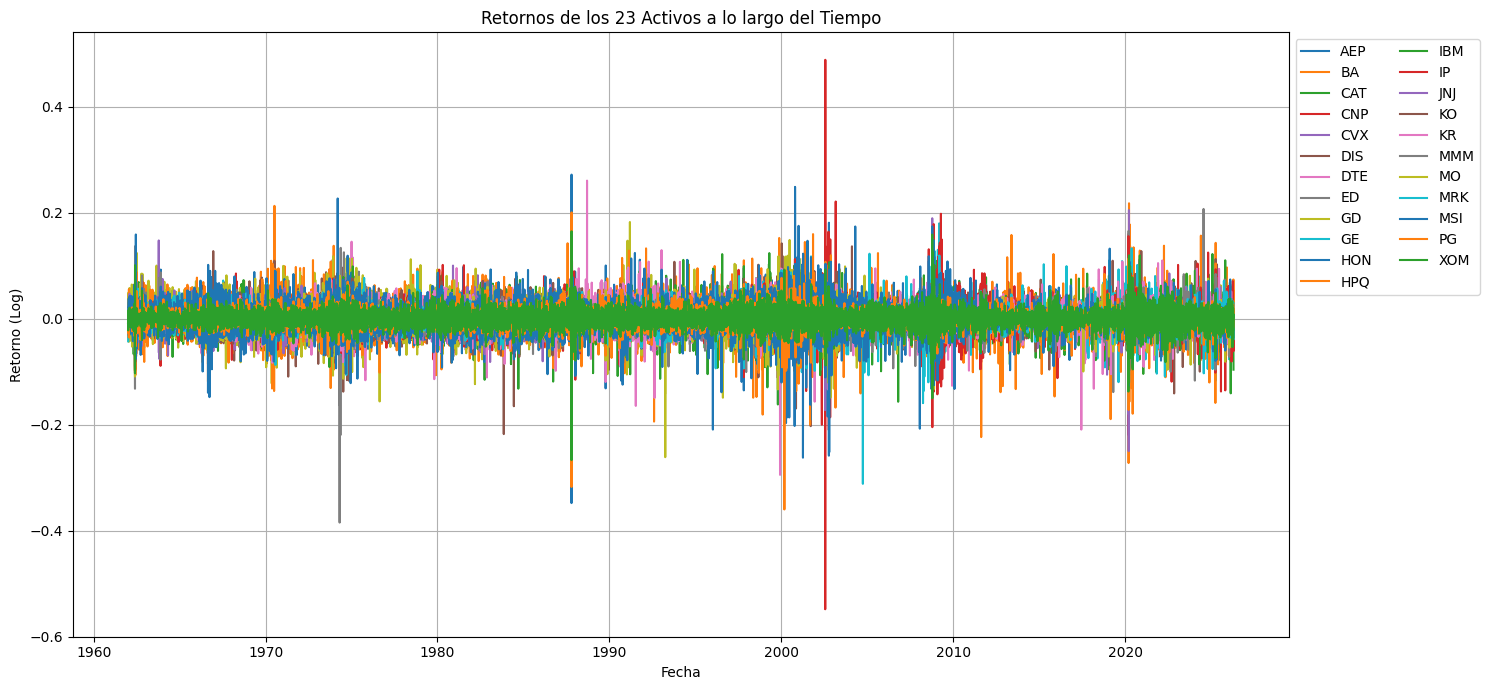

In [5]:
plt.figure(figsize=(15, 7))
plt.plot(returns)
plt.title('Retornos de los 23 Activos a lo largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Retorno (Log)')
plt.legend(returns.columns, loc='upper left', bbox_to_anchor=(1, 1), ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

# Partir los datos en ventanas

In [6]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

In [7]:
# Definir los tamaños de ventana
input_window_size = 30  # Por ejemplo, 10 días de retornos como entrada
output_window_size = 5 # Por ejemplo, el promedio del siguiente día como salida

# Generar series temporales para el conjunto de entrenamiento
X, y = create_time_series_data(returns, input_window_size, output_window_size)


In [8]:
print(X.shape)
print(y.shape)

(16150, 30, 23)
(16150, 23)


In [9]:
from sklearn.model_selection import train_test_split

# Set a random seed for reproducibility
RANDOM_SEED = 42

# Split the time series sequences X and y into training and testing sets (90% train, 10% test)
# shuffle=False is crucial for time series data to maintain chronological order
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X, y, test_size=0.1, shuffle=False, random_state=RANDOM_SEED
)

print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of y_test_seq: {y_test_seq.shape}")

Shape of X_train_seq: (14535, 30, 23)
Shape of y_train_seq: (14535, 23)
Shape of X_test_seq: (1615, 30, 23)
Shape of y_test_seq: (1615, 23)


# Regresion lineal

In [35]:
X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_train_seq, y_train_seq, test_size=0.05, shuffle=False, random_state=RANDOM_SEED
)

In [36]:
print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")
print(f"Shape of X_train_seq: {X_val_seq.shape}")
print(f"Shape of y_train_seq: {y_val_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of y_test_seq: {y_test_seq.shape}")

Shape of X_train_seq: (12426, 30, 23)
Shape of y_train_seq: (12426, 23)
Shape of X_train_seq: (655, 30, 23)
Shape of y_train_seq: (655, 23)
Shape of X_test_seq: (1615, 30, 23)
Shape of y_test_seq: (1615, 23)


In [38]:



num_samples_train = X_train_seq.shape[0]
num_samples_val = X_val_seq.shape[0]
num_samples_test = X_test_seq.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat = X_train_seq.reshape(num_samples_train, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat = X_val_seq.reshape(num_samples_val, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat = X_test_seq.reshape(num_samples_test, -1)

print(f"Shape of X_train_flat: {X_train_flat.shape}")
print(f"Shape of X_valn_flat: {X_val_flat.shape}")
print(f"Shape of X_test_flat: {X_test_flat.shape}")

Shape of X_train_flat: (12426, 690)
Shape of X_valn_flat: (655, 690)
Shape of X_test_flat: (1615, 690)


In [39]:
from sklearn.linear_model import LinearRegression

# Inicializar el modelo de regresión lineal
linear_model = LinearRegression()

# Entrenar el modelo con los datos aplanados
linear_model.fit(X_train_flat, y_train_seq)


# Realizar predicciones en el conjunto de prueba aplanado
y_pred_linear_tr = linear_model.predict(X_train_flat)

# Realizar predicciones en el conjunto de prueba aplanado
y_pred_linear_val = linear_model.predict(X_val_flat)

# Realizar predicciones en el conjunto de prueba aplanado
y_pred_linear_ts = linear_model.predict(X_test_flat)


In [40]:
np.mean(np.abs(y_pred_linear_tr-y_train_seq))

np.float64(0.005391521377853387)

In [41]:
np.mean(np.abs(y_pred_linear_val-y_val_seq))

np.float64(0.004441187835583368)

In [42]:
np.mean(np.abs(y_pred_linear_ts-y_test_seq))

np.float64(0.005890047589331865)

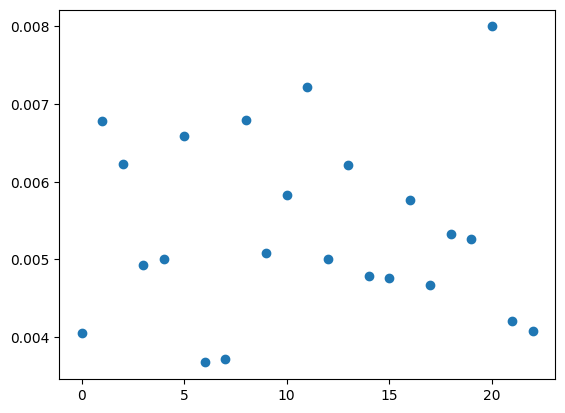

In [43]:
plt.plot(np.mean(np.abs(y_pred_linear_tr-y_train_seq),axis=0),'o')

# Para distintos tamaños de ventana

In [45]:
# Define input and output window sizes
input_window_sizes = [5, 10, 30, 90]
output_window_sizes = [1, 5, 30, 90]

# Initialize matrices to store MAE results
mae_train_matrix = np.zeros((len(input_window_sizes), len(output_window_sizes)))
mae_val_matrix = np.zeros((len(input_window_sizes), len(output_window_sizes)))
mae_test_matrix = np.zeros((len(input_window_sizes), len(output_window_sizes)))

# Loop through all combinations of window sizes
for i, input_ws in enumerate(input_window_sizes):
    for j, output_ws in enumerate(output_window_sizes):
        print(f"Processing Input Window Size: {input_ws}, Output Window Size: {output_ws}")

        # 1. Generate time series data
        X_current, y_current = create_time_series_data(returns, input_ws, output_ws)

        if X_current.size == 0 or y_current.size == 0:
            print(f"Skipping: Not enough data for input_ws={input_ws}, output_ws={output_ws}")
            mae_train_matrix[i][j] = np.nan
            mae_test_matrix[i][j] = np.nan
            continue

        # 2. Split data into training and testing sets
        X_train_seq_curr, X_test_seq_curr, y_train_seq_curr, y_test_seq_curr = train_test_split(
            X_current, y_current, test_size=0.1, shuffle=False, random_state=RANDOM_SEED
        )

        X_train_seq_curr, X_val_seq_curr, y_train_seq_curr, y_val_seq_curr = train_test_split(
              X_train_seq_curr, y_train_seq_curr, test_size=0.05, shuffle=False, random_state=RANDOM_SEED
          )

        # 3. Flatten X data for linear regression
        num_samples_train_curr = X_train_seq_curr.shape[0]
        num_samples_val_curr = X_val_seq_curr.shape[0]
        num_samples_test_curr = X_test_seq_curr.shape[0]

        X_train_flat_curr = X_train_seq_curr.reshape(num_samples_train_curr, -1)
        X_val_flat_curr = X_val_seq_curr.reshape(num_samples_val_curr, -1)
        X_test_flat_curr = X_test_seq_curr.reshape(num_samples_test_curr, -1)

        # 4. Initialize and train Linear Regression model
        linear_model_curr = LinearRegression()
        linear_model_curr.fit(X_train_flat_curr, y_train_seq_curr)

        # 5. Make predictions
        y_pred_linear_tr_curr = linear_model_curr.predict(X_train_flat_curr)
        y_pred_linear_val_curr = linear_model_curr.predict(X_val_flat_curr)
        y_pred_linear_ts_curr = linear_model_curr.predict(X_test_flat_curr)

        # 6. Calculate Mean Absolute Error (MAE)
        mae_train = np.mean(np.abs(y_pred_linear_tr_curr - y_train_seq_curr))
        mae_val = np.mean(np.abs(y_pred_linear_val_curr - y_val_seq_curr))
        mae_test = np.mean(np.abs(y_pred_linear_ts_curr - y_test_seq_curr))

        # Store MAE in matrices
        mae_train_matrix[i][j] = mae_train
        mae_val_matrix[i][j] = mae_val
        mae_test_matrix[i][j] = mae_test

print("\n--- MAE Training Matrix ---")
print("Rows: Input Window Sizes (5, 10, 30, 90)")
print("Columns: Output Window Sizes (1, 5, 30, 90)")
print(mae_train_matrix)

print("\n--- MAE Valid Matrix ---")
print("Rows: Input Window Sizes (5, 10, 30, 90)")
print("Columns: Output Window Sizes (1, 5, 30, 90)")
print(mae_val_matrix)

print("\n--- MAE Test Matrix ---")
print("Rows: Input Window Sizes (5, 10, 30, 90)")
print("Columns: Output Window Sizes (1, 5, 30, 90)")
print(mae_test_matrix)

Processing Input Window Size: 5, Output Window Size: 1
Processing Input Window Size: 5, Output Window Size: 5
Processing Input Window Size: 5, Output Window Size: 30
Processing Input Window Size: 5, Output Window Size: 90
Processing Input Window Size: 10, Output Window Size: 1
Processing Input Window Size: 10, Output Window Size: 5
Processing Input Window Size: 10, Output Window Size: 30
Processing Input Window Size: 10, Output Window Size: 90
Processing Input Window Size: 30, Output Window Size: 1
Processing Input Window Size: 30, Output Window Size: 5
Processing Input Window Size: 30, Output Window Size: 30
Processing Input Window Size: 30, Output Window Size: 90
Processing Input Window Size: 90, Output Window Size: 1
Processing Input Window Size: 90, Output Window Size: 5
Processing Input Window Size: 90, Output Window Size: 30
Processing Input Window Size: 90, Output Window Size: 90

--- MAE Training Matrix ---
Rows: Input Window Sizes (5, 10, 30, 90)
Columns: Output Window Sizes (

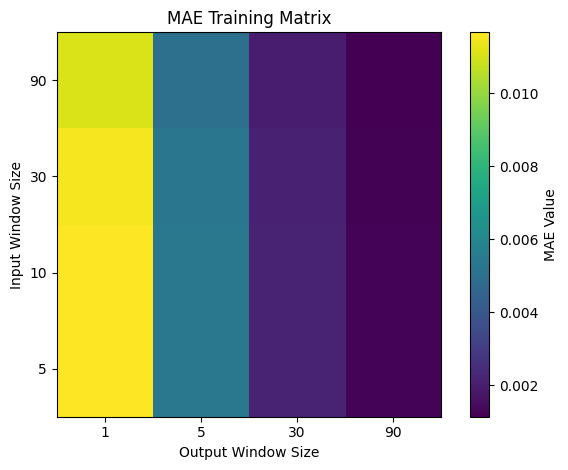

In [46]:
plt.imshow(mae_train_matrix, cmap='viridis', origin='lower')
plt.xlabel('Output Window Size')
plt.ylabel('Input Window Size')
plt.title('MAE Training Matrix')
plt.xticks(ticks=np.arange(len(output_window_sizes)), labels=output_window_sizes)
plt.yticks(ticks=np.arange(len(input_window_sizes)), labels=input_window_sizes)
plt.colorbar(label='MAE Value')
plt.tight_layout()
plt.show()

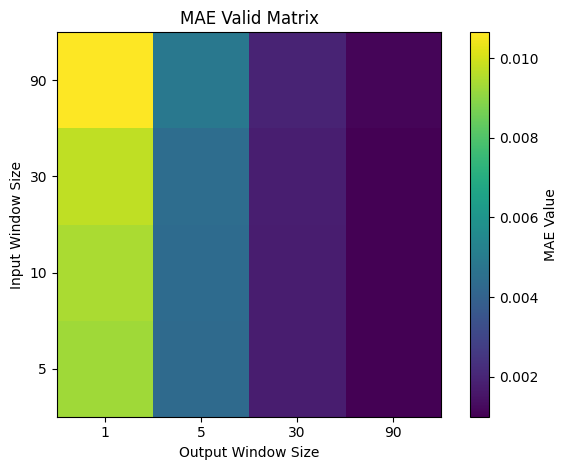

In [47]:
plt.imshow(mae_val_matrix, cmap='viridis', origin='lower')
plt.xlabel('Output Window Size')
plt.ylabel('Input Window Size')
plt.title('MAE Valid Matrix')
plt.xticks(ticks=np.arange(len(output_window_sizes)), labels=output_window_sizes)
plt.yticks(ticks=np.arange(len(input_window_sizes)), labels=input_window_sizes)
plt.colorbar(label='MAE Value')
plt.tight_layout()
plt.show()

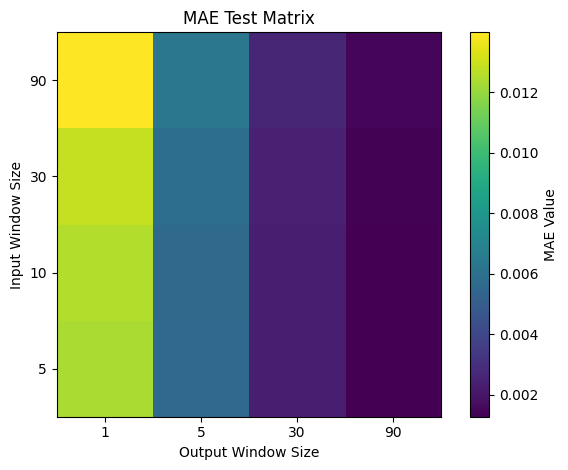

In [48]:
plt.imshow(mae_test_matrix, cmap='viridis', origin='lower')
plt.xlabel('Output Window Size')
plt.ylabel('Input Window Size')
plt.title('MAE Test Matrix')
plt.xticks(ticks=np.arange(len(output_window_sizes)), labels=output_window_sizes)
plt.yticks(ticks=np.arange(len(input_window_sizes)), labels=input_window_sizes)
plt.colorbar(label='MAE Value')
plt.tight_layout()
plt.show()